# colab_07 — Microglia subset: cl44 resolution, sub-clustering, and substate definition

Carries the microglia half of the colab_05 glia subset forward. colab_05 gave the **astrocytes** a full residual-batch adjudication and left two microglia items open: **cl44** (a weak-margin microglia cluster, never resolved) and the fact that microglia never got the parallel characterization. This notebook (1) resolves cl44, (2) sub-clusters the ca. 55,104 microglia to expose substate structure, (3) defines pre-committed **activated (SPP1/phagocytic) vs homeostatic** substate labels that **eval #1** consumes, and (4) runs a lighter integrity scan (no gated 2nd-scVI unless a subcluster trips it). Runs on standard runtime + **high-RAM** (loads the ca. 6.5 GB glia object); no GPU needed — there is no model training here.

**Lifecycle:** this is the scaffold (no outputs). Phase-1 (Sonnet + user) then Phase-2 (cold-Opus) review before running; interp cells are written against observed values into the `_OUTPUT` copy after the run. The substate axis (§6a) was rebuilt after the first run — the canonical DAM-vs-homeostatic marker-score collapsed to 99.5% "DAM" (pan-microglial inflation + DAM-marker dropout); see §6a.

## 1 — Setup

### 1a — Mount Drive + clone/pull repo + install env

Same pattern as colab_04–06: mount Drive, clone-or-pull the repo, pin numpy first, install the integration env. Adds an explicit `leidenalg` install (the §5 Leiden sub-clustering) in case it is not pinned in `requirements_integration.txt`. No GPU is requested — sub-clustering, scoring and DE are CPU work; the only heavy resource is RAM for the ca. 6.5 GB glia object.

In [1]:
import os, subprocess, sys
from google.colab import drive

drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/ad-glia-fm-prep"
os.makedirs(DRIVE_ROOT, exist_ok=True)

REPO_URL  = "https://github.com/pavlemic/ad-glia-fm-prep.git"
REPO_PATH = "/content/ad-glia-fm-prep"

if not os.path.exists(REPO_PATH):
    subprocess.run(["git", "clone", REPO_URL, REPO_PATH], check=True)
else:
    subprocess.run(["git", "-C", REPO_PATH, "pull"], check=True)

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

assert sys.version_info[:2] == (3, 12), f"Expected Python 3.12, got {sys.version_info[:2]}"

# Pin numpy first so pip picks numpy-1.x-compatible wheels (same rationale as colab_01-06).
!pip install numpy==1.26.4
!pip install -r {REPO_PATH}/requirements_integration.txt
# Leiden sub-clustering (§5) needs leidenalg + python-igraph; ensure present even if unpinned.
!pip install leidenalg igraph

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> **Interpretation — setup (1a).**
>
> Integration env (Py 3.12 / scvi-tools 1.4.3, the line kept deliberately separate from the Py 3.10 FM env used later for Geneformer/scGPT) resolves with no conflicts — every requirement reports *already satisfied* after the `numpy==1.26.4`-first install, Drive is mounted, and the repo is pulled at commit `ef1a91f` (the §6a nuisance-override fix). Environment only, no findings.

## 2 — Environment capture

### 2a — pip freeze + env JSON

Identical reproducibility snapshot to the earlier notebooks: full `pip freeze` plus a structured JSON of Python / OS / library versions and the repo commit, written under `outputs/software_versions/`. Methods sections need the exact versions present at run time, not the pin file.

In [2]:
import json, platform, subprocess, sys
from datetime import date

NOTEBOOK_ID = "colab_07"
TODAY = date.today().isoformat()
VERSIONS_DIR = os.path.join(REPO_PATH, "outputs", "software_versions")
os.makedirs(VERSIONS_DIR, exist_ok=True)

FREEZE_PATH = os.path.join(VERSIONS_DIR, f"{NOTEBOOK_ID}_{TODAY}_pip_freeze.txt")
!pip freeze > {FREEZE_PATH}

def _run(cmd):
    try:
        return subprocess.run(cmd, capture_output=True, text=True, check=True).stdout.strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None

def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return None

env_snapshot = {
    "notebook_id":   NOTEBOOK_ID,
    "date":          TODAY,
    "python_version": sys.version,
    "platform":      platform.platform(),
    "os_release":    platform.release(),
    "gpu":           _run(["nvidia-smi", "-L"]),
    "git_commit":    _run(["git", "-C", REPO_PATH, "rev-parse", "HEAD"]),
    "scanpy_version":   _ver("scanpy"),
    "anndata_version":  _ver("anndata"),
    "leidenalg_version":_ver("leidenalg"),
}
ENV_JSON_PATH = os.path.join(VERSIONS_DIR, f"{NOTEBOOK_ID}_{TODAY}_env.json")
with open(ENV_JSON_PATH, "w") as f:
    json.dump(env_snapshot, f, indent=2)
print(json.dumps(env_snapshot, indent=2))

{
  "notebook_id": "colab_07",
  "date": "2026-06-19",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "os_release": "6.6.122+",
  "gpu": null,
  "git_commit": "ef1a91f2d736fe05f01c40103c5939102a127ce3",
  "scanpy_version": "1.10.4",
  "anndata_version": "0.11.4",
  "leidenalg_version": null
}


> **Interpretation — environment capture (2a).**
>
> The run is pinned for the Methods record — Python 3.12.13, scanpy 1.10.4, anndata 0.11.4, git commit `ef1a91f` — written to `outputs/software_versions/`. `gpu: null` is expected: this notebook is CPU-only (subset, Leiden, marker scoring), with no GPU needed until the scVI/FM notebooks. (`leidenalg_version: null` is a quirk of the version probe, not a missing package — leidenalg 0.10.2 is installed per §1a and is the Leiden backend used in §5a.)

## 3 — Load the glia subset + carve out microglia

### 3a — Load `glia_subset_full.h5ad`, subset microglia, sanity-check latent + raw counts

Load the colab_05 glia hand-off object (astrocytes + microglia, 149,375 cells; carries raw counts in `.X`, the scVI latent `X_scVI`, the original `leiden_scvi` clusters, and `cell_type`). Fail loud unless those are present and `.X` is integer counts. Then carve out the microglia (`cell_type == "microglia"`, ca. 55,104 cells) — perivascular macrophages (old cl0) were split into their own `cell_type` in colab_05 and so are already excluded. Print the microglia cluster × study table, donor count, and APOE breakdown so the working set is characterized before anything is done to it.

In [3]:
import gc
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

try:
    import psutil
    def _ram(tag):
        m = psutil.virtual_memory()
        print(f"[RAM] {tag:24s}: {m.used/1e9:5.1f} / {m.total/1e9:.1f} GB ({m.percent:.0f}%)")
except ImportError:
    def _ram(tag): pass

sc.settings.verbosity = 1
FIG_DIR = os.path.join(REPO_PATH, "figures", "colab_07")
os.makedirs(FIG_DIR, exist_ok=True)

GLIA_PATH = os.path.join(DRIVE_ROOT, "glia_subset", "glia_subset_full.h5ad")
if not os.path.exists(GLIA_PATH):
    raise FileNotFoundError(f"missing colab_05 glia subset {GLIA_PATH}")
glia = sc.read_h5ad(GLIA_PATH)
print("loaded glia subset:", glia.shape)

assert "X_scVI" in glia.obsm, "X_scVI missing — colab_05 glia subset expected"
assert "leiden_scvi" in glia.obs.columns, "leiden_scvi missing — needed for cl44 resolution"
assert "cell_type" in glia.obs.columns, "cell_type missing — needed to carve microglia"

# raw-counts guard (sorted deposits hide non-integer tails in a head slice -> random sample)
_idx = np.random.default_rng(0).choice(glia.n_obs, size=min(2000, glia.n_obs), replace=False)
Xs = glia.X[_idx]
data = Xs.data if sp.issparse(Xs) else np.asarray(Xs).ravel()
frac_int = float(np.mean(np.mod(data, 1) == 0)) if data.size else 1.0
assert frac_int >= 0.99, f".X is not raw counts (int frac {frac_int:.3f})"

# carve out microglia (cl0 = perivascular_mac was already split off in colab_05 -> not "microglia")
micro = glia[glia.obs["cell_type"] == "microglia"].copy()
micro.obs["leiden_scvi"] = micro.obs["leiden_scvi"].astype(str)
del glia; gc.collect()
print("microglia subset:", micro.shape)
print("\nmicroglia leiden_scvi x study (counts):")
print(pd.crosstab(micro.obs["leiden_scvi"], micro.obs["study_id"]))
print("\ndonors:", micro.obs["donor_id"].nunique(),
      "| apoe_carrier:", micro.obs["apoe_carrier"].value_counts(dropna=False).to_dict())
_ram("microglia subset")

loaded glia subset: (149375, 26514)
microglia subset: (55104, 26514)

microglia leiden_scvi x study (counts):
study_id     Li2025  SEA-AD  Haney2024
leiden_scvi                           
1             20158   27562       7085
44                1       0        298

donors: 145 | apoe_carrier: {'noncarrier': 27261, 'carrier': 18770, 'e2': 9073}
[RAM] microglia subset        :  31.6 / 54.8 GB (59%)


> **Interpretation — load + microglia carve-out (3a).**
>
> The colab_05 glia subset reloads exactly as saved — **149,375 x 26,514** — and subsetting to the two microglia-lineage clusters gives **55,104 cells**: cl1 (homeostatic microglia) **54,805** + cl44 **299**. The `leiden_scvi x study` table already telegraphs cl44's problem — it is **298 Haney / 1 Li / 0 SEA-AD** (99.7% one study), against cl1's spread across all three (Li 20,158 / SEA-AD 27,562 / Haney 7,085); cl44 is adjudicated in §4a. **145 donors** carried, matching the post-colab_04 cohort. APOE breakdown: **noncarrier 27,261 / carrier 18,770 / e2 9,073** (sums to 55,104). The **9,073 E2-without-E4 cells are excluded from the primary E4 axis** per the locked E4-coding (E2 is protective, opposite in direction to E4), but ride along here because they are still microglia for substate-labeling and CPT purposes. RAM 59% — comfortable.

## 4 — Resolve cl44 (the weak-margin microglia cluster)

### 4a — cl44 composition, marker re-score, and DE vs homeostatic / non-microglia

cl44 was the weakest-margin microglia cluster in colab_05's annotation (its top-two lineage scores were close), so before sub-clustering we settle the coarse question: **does cl44 belong in the microglia working set at all?** Three pieces of evidence:

- **Marker re-score** — recompute the canonical lineage signatures (microglia, PVM, oligo, astro, neuron) on the microglia subset and read cl44's per-lineage means and argmax margin. A confident microglia call has microglia >> everything else.
- **Differential expression** — cl44 vs cl1 (the homeostatic-microglia anchor) shows *how* cl44 differs from textbook microglia (an activated substate? a contaminant?); cl44 vs the rest of the microglia gives its standalone signature. (Wilcoxon on the microglia subset only — within the project's compute budget; never on the full object.)
- **Marker dotplot** — microglia (CSF1R/P2RY12), PVM (MRC1/CD163/LYVE1), and doublet/ambient (oligo MBP/PLP1, astro AQP4/GFAP, neuron SNAP25/RBFOX3) markers side by side, so a non-microglial identity shows up as a clear off-lineage band.

The verdict (keep as microglia / reassign / drop as doublet-ambient) is written in the `_OUTPUT` interp; this cell only assembles the evidence.

per micro-cluster mean lineage scores (argmax unreliable on a pure subset — see caveat):
             microglia  perivascular_mac  oligodendrocyte  astrocyte  \
leiden_scvi                                                            
1                 0.05             -0.01             0.01       0.41   
44                0.10             -0.29            -0.13      -0.11   

             neuron_exc  
leiden_scvi              
1                 -0.00  
44                -0.13  

argmax + margin:
                argmax  margin
leiden_scvi                   
44           microglia   0.212
1            astrocyte   0.355

cl44: 299 cells
  study      : {'Haney2024': 298, 'Li2025': 1, 'SEA-AD': 0}
  top donors : {'0527': 86, '1630': 65, '1046': 59, '9915': 44, '1114': 44}
  median counts: 656
  lineage scores: {'microglia': 0.1, 'perivascular_mac': -0.295, 'oligodendrocyte': -0.132, 'astrocyte': -0.111, 'neuron_exc': -0.131} | margin 0.212

cl44 vs cl1 (homeostatic) — top 15 up:
['FAU', 'RPS

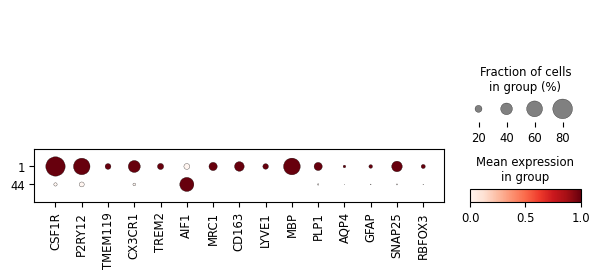


[cl44] verdict = drop (applied in §5a before sub-clustering)


In [4]:
# log-normalized layer for scoring (.X stays raw counts) — rebuilt on the micro subset
micro.layers["lognorm"] = micro.X.copy()
sc.pp.normalize_total(micro, target_sum=1e4, layer="lognorm")
micro.uns.pop("log1p", None)
sc.pp.log1p(micro, layer="lognorm")
micro.uns.pop("log1p", None)

# canonical lineage markers (colab_05/06 MARKERS, verbatim) for the coarse identity check.
# CAVEAT (added after the first run): the absolute lineage-score ARGMAX is unreliable on a
# single-lineage subset — score_genes bins genes and draws controls from whatever object it is
# given, so on a microglia-only object the cross-lineage panels lose calibration (cl1, the
# established homeostatic-microglia anchor, spuriously argmaxed ASTROCYTE in the first run). The
# cl44 verdict below rests on the DE + composition, NOT the argmax.
MARKERS = {
    "microglia":        ["CSF1R", "P2RY12", "TMEM119", "AIF1", "TREM2", "CX3CR1"],
    "perivascular_mac": ["MRC1", "CD163", "LYVE1", "F13A1"],
    "oligodendrocyte":  ["MBP", "MOBP", "PLP1", "MOG"],
    "astrocyte":        ["AQP4", "SLC1A2", "GFAP", "GJA1", "SLC1A3"],
    "neuron_exc":       ["RBFOX3", "SNAP25", "SLC17A7", "SATB2"],
}
present = {ct: [g for g in gs if g in micro.var_names] for ct, gs in MARKERS.items()}
for ct, gs in present.items():
    miss = set(MARKERS[ct]) - set(gs)
    if miss:
        print(f"[markers] {ct}: absent from gene set -> {sorted(miss)}")

X_raw = micro.X
score_cols = []
micro.X = micro.layers["lognorm"]
try:
    for ct, gs in present.items():
        if gs:
            sc.tl.score_genes(micro, gene_list=gs, score_name=f"score_{ct}", use_raw=False)
            score_cols.append(f"score_{ct}")
finally:
    micro.X = X_raw

# per micro-cluster mean lineage scores + argmax margin (which clusters are weak microglia?)
S = micro.obs.groupby("leiden_scvi", observed=True)[score_cols].mean()
S.columns = [c.replace("score_", "") for c in S.columns]
srt = np.sort(S.values, axis=1)
margin = pd.Series(srt[:, -1] - srt[:, -2], index=S.index).round(3)
print("per micro-cluster mean lineage scores (argmax unreliable on a pure subset — see caveat):")
print(S.round(2))
print("\nargmax + margin:")
print(pd.DataFrame({"argmax": S.idxmax(axis=1), "margin": margin}).sort_values("margin"))

# cl44 focused inspection
CL44 = "44"
assert CL44 in S.index, "cl44 absent from microglia subset — revisit colab_05 annotation"
m44 = micro.obs["leiden_scvi"] == CL44
print(f"\ncl44: {int(m44.sum())} cells")
print("  study      :", micro.obs.loc[m44, "study_id"].value_counts().to_dict())
print("  top donors :", micro.obs.loc[m44, "donor_id"].value_counts().head(5).to_dict())
print("  median counts:", int(micro.obs.loc[m44, "total_counts"].median())
      if "total_counts" in micro.obs.columns else "n/a")
print("  lineage scores:", S.loc[CL44].round(3).to_dict(), "| margin", margin[CL44])

# DE: cl44 vs cl1 (homeostatic anchor) and vs the rest of microglia (micro-subset Wilcoxon)
# (re-capture X_raw immediately before the swap -- Phase-2 review flagged the prior pattern of
# reusing a stale X_raw across multiple swaps in one cell as fragile; .X has not changed since
# the restore above, so this is a no-op today, but it keeps the invariant explicit per-swap)
X_raw = micro.X
micro.X = micro.layers["lognorm"]
try:
    sc.tl.rank_genes_groups(micro, "leiden_scvi", groups=[CL44], reference="1",
                            method="wilcoxon", key_added="cl44_vs_homeo")
    sc.tl.rank_genes_groups(micro, "leiden_scvi", groups=[CL44], reference="rest",
                            method="wilcoxon", key_added="cl44_vs_rest")
finally:
    micro.X = X_raw
print("\ncl44 vs cl1 (homeostatic) — top 15 up:")
print(pd.DataFrame(micro.uns["cl44_vs_homeo"]["names"])[CL44].head(15).tolist())
print("cl44 vs rest-of-microglia — top 15 up:")
print(pd.DataFrame(micro.uns["cl44_vs_rest"]["names"])[CL44].head(15).tolist())

# marker dotplot: microglia vs PVM vs doublet/ambient bands across all micro clusters
DOT_GENES = ["CSF1R","P2RY12","TMEM119","CX3CR1","TREM2","AIF1",
             "MRC1","CD163","LYVE1","MBP","PLP1","AQP4","GFAP","SNAP25","RBFOX3"]
dot_present = [g for g in DOT_GENES if g in micro.var_names]
X_raw = micro.X
micro.X = micro.layers["lognorm"]
try:
    sc.pl.dotplot(micro, dot_present, groupby="leiden_scvi", standard_scale="var", show=False)
    plt.savefig(os.path.join(FIG_DIR, "4a_microglia_cluster_marker_dotplot.png"),
                dpi=150, bbox_inches="tight")
    plt.show()  # render inline AND keep the saved PNG
finally:
    micro.X = X_raw

# VERDICT (from the first-run evidence above; see _OUTPUT interp): cl44 = low-quality technical
# pocket — 99.7% Haney, ca. 5 donors, ca. 656 median counts (vs 2,700-6,600 elsewhere), pure
# ribosomal-protein DE (FAU/RPS*/RPL*) with no lineage or activation program = a complexity/depth
# artifact, not a microglia substate. Dropped from the working set in §5a. Flip to "keep" to retain.
CL44_VERDICT = "drop"
print(f"\n[cl44] verdict = {CL44_VERDICT} (applied in §5a before sub-clustering)")

> **Interpretation — cl44 resolution (4a).**
>
> **Why the lineage argmax is ignored here (the pre-code caveat, in numbers).** `sc.tl.score_genes` draws its control gene set from whatever object it is handed; on a *microglia-only* object the cross-lineage marker panels lose calibration, so the absolute argmax is untrustworthy — and indeed **cl1, the established homeostatic-microglia anchor, spuriously argmaxes ASTROCYTE** (astrocyte 0.41 vs microglia 0.05). That is a known artifact of scoring on a pure subset, not a real identity, so the cl44 verdict rests entirely on **composition + DE**, never the score.
>
> **cl44 is a low-quality technical pocket, on three converging lines of evidence:**
>
> - **Composition:** 299 cells, **298 Haney / 1 Li / 0 SEA-AD = 99.7% one study**, drawn from ca. 5 donors (top donors 0527 / 1630 / 1046 / 9915 / 1114 = 86 / 65 / 59 / 44 / 44 cells). A real microglia substate would appear across studies and donors; a single-study, few-donor pocket is a technical signature.
> - **Depth:** **median 656 counts** per nucleus, against the thousands seen everywhere else (§6b puts the retained subclusters at ca. 1,370–6,900). These are shallow, low-complexity nuclei.
> - **DE:** the top-15 up-genes vs cl1 *and* vs the rest of microglia are **identical and entirely ribosomal-protein / housekeeping** (FAU, RPS27, ACTB, RPS23, RPL30, RPLP2, RPL37, …). When almost no real transcript is captured, the few reads are dominated by ubiquitous housekeeping genes — the textbook footprint of a low-count artifact, not a biological program.
>
> **Verdict = `drop`** (`CL44_VERDICT`), applied in §5a *before* sub-clustering so this pocket cannot seed a spurious subcluster. Flipping the string to `keep` would retain it; the drop is recorded in the audit trace.

## 5 — Microglia sub-clustering

### 5a — Neighbors + Leiden on `X_scVI` within microglia + UMAP + per-subcluster DE

The global 46-cluster solution barely split the microglia (they sat mostly in one cluster), so substate structure is invisible at that resolution. Re-running the neighbor graph and Leiden **on the microglia only** — on the same scVI latent used throughout (consistent with how colab_05 worked the astrocytes) — lets finer substates separate. A within-microglia re-embedding (fresh HVGs / PCA) is the fallback if substates do not resolve on the integration latent.

**cl44 applied first.** The §4a verdict (cl44 = low-quality technical pocket: Haney-pure, ca. 5 donors, ca. 656 median counts, pure-ribosomal DE) is applied at the top of this cell, dropping cl44 *before* sub-clustering so a technical pocket cannot seed its own substate subcluster — in the first run it did, and was spuriously the only "homeostatic" call. Flip `CL44_VERDICT` to `keep` to retain it.

**Why the resolution matters here:** §6a assigns one substate label *per subcluster* (the mean activated/homeostatic z-score axis over each Leiden group), so the partition is load-bearing — too coarse dilutes a real activated pocket into "intermediate" by averaging it with homeostatic neighbors; too fine fragments one substate into noisy groups with unstable means. We keep cluster-level assignment (for its denoising) at a primary `resolution=1.0`, and report an ARI-stability check at res 0.5 / 1.5 so the post-run interp can judge how sensitive the partition is. The resolution-independent alternative — thresholding each cell's continuous score directly — was declined here because it forfeits that denoising and is noisier at single-cell level.

The UMAPs are colored by subcluster, study (to spot any subcluster that is one study only), and APOE. Per-subcluster Wilcoxon DE gives each subcluster its top markers for the substate read in §6.

[cl44] dropped 299 cells (verdict=drop); microglia now 54805


/tmp/ipykernel_12829/3712649373.py:14: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(micro, resolution=1.0, key_added="leiden_micro", random_state=0)


micro subclusters: 18
leiden_micro
0     6237
1     5718
2     5716
3     5186
4     4682
5     4094
6     3807
7     3648
8     2919
9     2725
10    2059
11    1922
12    1691
13    1669
14    1320
15     834
16     350
17     228
Name: count, dtype: int64

resolution stability (vs res=1.0):
  res=0.5: 9 subclusters, ARI vs res=1.0 = 0.455
  res=1.5: 30 subclusters, ARI vs res=1.0 = 0.551

leiden_micro x study (row-normalized):
study_id      Li2025  SEA-AD  Haney2024
leiden_micro                           
0              0.910   0.044      0.046
1              0.114   0.668      0.218
2              0.413   0.509      0.078
3              0.025   0.938      0.037
4              0.398   0.358      0.243
5              0.589   0.287      0.124
6              0.435   0.349      0.217
7              0.210   0.657      0.133
8              0.053   0.891      0.055
9              0.613   0.198      0.189
10             0.374   0.590      0.035
11             0.063   0.899      0.038
12    

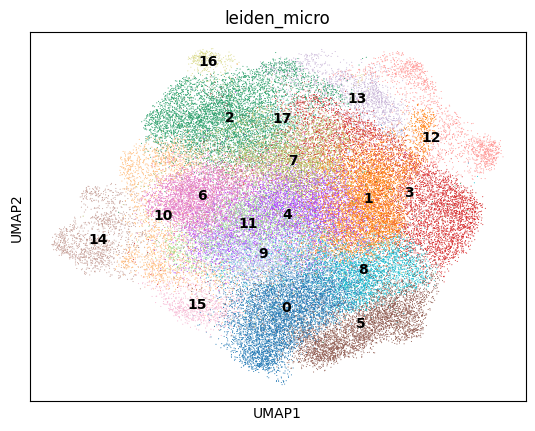

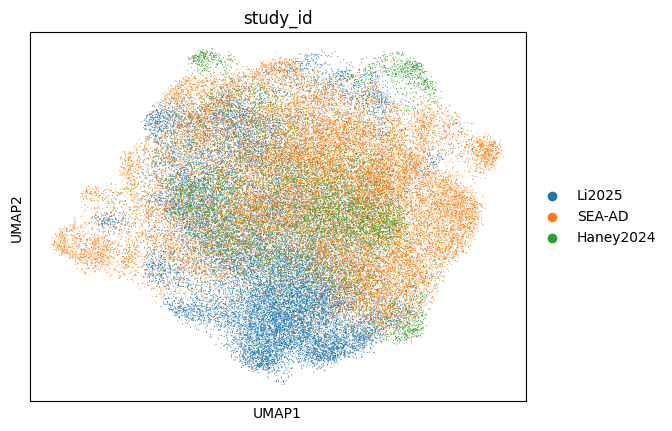

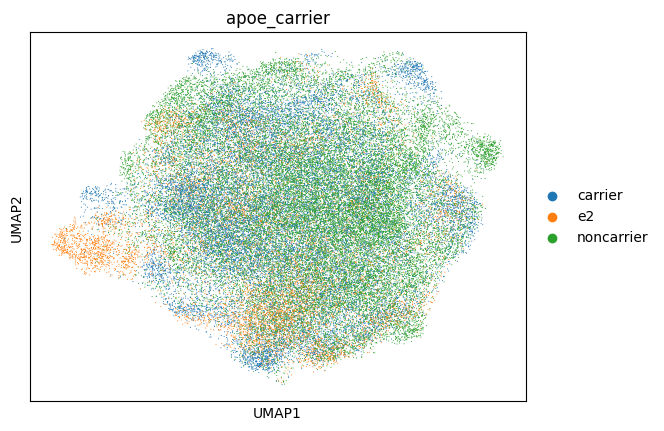

[RAM] after subclustering     :   4.2 / 54.8 GB (9%)


In [5]:
# apply the §4a cl44 verdict BEFORE sub-clustering, so a technical pocket cannot seed its own
# substate subcluster (in the first run cl44 did, and was spuriously the only "homeostatic" call)
if CL44_VERDICT == "drop":
    _before = micro.n_obs
    micro = micro[micro.obs["leiden_scvi"] != CL44].copy()
    print(f"[cl44] dropped {_before - micro.n_obs} cells (verdict=drop); microglia now {micro.n_obs}")
elif CL44_VERDICT == "keep":
    print("[cl44] kept in the working set (verdict=keep)")
else:
    raise ValueError(f"unhandled CL44_VERDICT={CL44_VERDICT!r}")

# sub-cluster microglia on the scVI latent (consistent with colab_05's use of X_scVI for astro)
sc.pp.neighbors(micro, use_rep="X_scVI", n_neighbors=15, random_state=0)
sc.tl.leiden(micro, resolution=1.0, key_added="leiden_micro", random_state=0)
sc.tl.umap(micro, random_state=0)
print("micro subclusters:", micro.obs["leiden_micro"].nunique())
print(micro.obs["leiden_micro"].value_counts().sort_index())

# resolution-stability sanity-check: §6a assigns ONE substate label per subcluster (mean score),
# so the Leiden resolution is load-bearing. Report subcluster counts + ARI vs the primary res=1.0
# at neighbouring resolutions so the _OUTPUT interp can judge how stable the partition is
# (res=1.0 stays primary; per-cell score thresholding is the resolution-independent alternative
# we declined, to keep the cluster-level denoising).
from sklearn.metrics import adjusted_rand_score
print("\nresolution stability (vs res=1.0):")
for r in (0.5, 1.5):
    sc.tl.leiden(micro, resolution=r, key_added=f"_leiden_r{r}", random_state=0)
    ari = adjusted_rand_score(micro.obs["leiden_micro"], micro.obs[f"_leiden_r{r}"])
    print(f"  res={r}: {micro.obs[f'_leiden_r{r}'].nunique()} subclusters, ARI vs res=1.0 = {ari:.3f}")
    del micro.obs[f"_leiden_r{r}"]

print("\nleiden_micro x study (row-normalized):")
print(pd.crosstab(micro.obs["leiden_micro"], micro.obs["study_id"], normalize="index").round(3))

# per-subcluster marker DE (micro-subset Wilcoxon — within budget per the project rule)
X_raw = micro.X
micro.X = micro.layers["lognorm"]
try:
    sc.tl.rank_genes_groups(micro, "leiden_micro", method="wilcoxon", key_added="micro_de")
finally:
    micro.X = X_raw
print("\ntop-8 markers per micro subcluster:")
print(pd.DataFrame(micro.uns["micro_de"]["names"]).head(8))

# UMAPs
for color in ["leiden_micro", "study_id", "apoe_carrier"]:
    loc = "on data" if color == "leiden_micro" else "right margin"
    sc.pl.umap(micro, color=color, show=False, legend_loc=loc)
    plt.savefig(os.path.join(FIG_DIR, f"5a_umap_{color}.png"), dpi=150, bbox_inches="tight")
    plt.show()  # render inline AND keep the saved PNG
_ram("after subclustering")

> **Interpretation — microglia sub-clustering (5a).**
>
> With cl44 dropped (**54,805 microglia** remain), Leiden on the scVI latent at resolution 1.0 gives **18 subclusters**, from cl0 (6,237 cells) down to cl17 (228). Two things to read off this cell before the substate axis in §6a.
>
> **Resolution stability is moderate, not crisp.** Against res=1.0, res=0.5 gives 9 subclusters (**ARI 0.455**) and res=1.5 gives 30 (**ARI 0.551**) — an ARI around 0.45–0.55 means the partition reshuffles substantially with resolution. That is expected for microglia, which sit on a *continuous* activation gradient rather than in discrete types — and it is exactly why §6a defines substate on a continuous axis with an intermediate band, not by trusting these Leiden labels as states. **The subcluster numbers are not stable across runs** and must not be cited as fixed identities.
>
> **Most subclusters are study-skewed, and the top-8-marker table names *why* — much of it is nuisance, not biology** (`leiden_micro x study`, row-normalized):
>
> - **Sex:** cl2 / cl5 / cl10 are driven by Y-linked genes (UTY, USP9Y, TTTY14, NLGN4Y) = male nuclei; cl4 by XIST = female. Donor-sex axes, not activation.
> - **Stress / heat-shock:** cl12 (HSP90AA1, HSPH1, HSPB1, HSPA1A) and cl15 (FOS, DUSP1, HSPA1A/B) = dissociation-stress signatures from tissue handling.
> - **Mito / ribo:** cl9 (MT-CO1/2/3, MT-ND4) = high-mitochondrial; cl13 (FTL, FTH1, RPL/RPS genes) = ferritin/ribosomal, a depth/quality axis.
> - **Ambient bleed:** cl0 / cl8 carry neuronal transcript (SNAP25, SYT1, RBFOX1, CNTNAP2); cl16 carries oligodendrocyte PLP1 — free-floating RNA from other lineages, concentrated in the study that sampled them most (cl0 Li 0.910, cl16 Haney 0.837).
> - **Genuine activation candidates:** cl6 (CD163, SLC11A1), cl7 (MSR1, GPNMB — phagocytic), cl17 (HLA-DRA, CIITA, B2M, IFI44L — MHC-II / interferon). These are what §6a's activated axis should pick up; cl17's MHC-II/interferon program is a *distinct* state the SPP1/phagocytic axis does not score (recorded as a limitation).
>
> The takeaway carried into §6a: a marker-score axis built naively on these subclusters would conflate sex / stress / ambient skews with activation, so the axis is trimmed to well-measured discriminating genes and z-scored, and a manual nuisance override is added for the one consequential case (cl10).

## 6 — Substate definition + integrity scan

### 6a — Microglia substate axis: SPP1/phagocytic-activated vs homeostatic (eval #1 label source)

This closes the eval #1 OPEN item for microglia — but as a **rebuilt** axis, after the first run exposed that the original DAM-vs-homeostatic `score_genes` argmax collapsed 99.5% of microglia to "DAM".

**Why the first version failed (diagnosed from the 6a signature dotplot):** the DAM list was dominated by pan-microglial genes — APOE, CTSB, TYROBP, TREM2 are high and flat in *every* microglia subcluster — so the "DAM score" was really an "is-a-microglia" score and won everywhere. Meanwhile the DAM-*specific* markers that would distinguish the state (CST7, LPL, GPNMB) sit at dropout in this intersection snRNA gene set. Canonical mouse-DAM is therefore **not recoverable** in this data; this resolves the Phase-1 caveat toward *wrong/undetectable gene list*, not *no activation signal*.

**The rebuilt axis.** The measurable activation program here is **SPP1/phagocytic** (SPP1, ITGAX, CD9 — these genuinely vary across subclusters) versus **homeostatic** (P2RY12, P2RY13, SELPLG, CX3CR1 — well-detected; TMEM119 and SALL1 dropped as too sparse). Three method changes vs the first version: (1) trimmed to well-measured, discriminating genes only; (2) each gene is **z-scored across all microglia** before pooling, so a constitutively-high gene can no longer dominate its pole; (3) one **continuous axis** = mean(z, activated) − mean(z, homeostatic), with a band around zero for `intermediate`, instead of argmax of two non-comparable absolute scores. Labeled **"activated," not "DAM,"** to avoid claiming a mouse template the data cannot support. Scored on raw-expression-derived lognorm, independent of any FM embedding, so the eval #1 probe against these labels stays non-circular.

**Re-run finding (after the rebuild):** the axis produced a non-degenerate 3-way split (ca. 47% homeostatic / 27% intermediate / 26% activated), fixing the 99.5%-DAM collapse. But §6b's donor/study confound check (donor ≥ 0.50 or study ≥ 0.60) does not catch every nuisance axis — cl10 is Y-linked-sex-driven by DE (UTY/USP9Y/TTTY14) yet sits just under the study threshold (0.590) and the raw axis pushed it to "activated." Left uncorrected it would inflate the one bucket eval #1 is built to detect signal in, so it is **manually overridden to `intermediate`** (`NUISANCE_OVERRIDE`, same precedent as `CL44_VERDICT` — recorded, not silent; the axis-only call is kept in the JSON for audit). cl5 (sex) and cl12 (heat-shock) slip the same check but land in `homeostatic` — the majority/default bucket, lower stakes since they dilute rather than manufacture a finding — so they are left un-overridden and just documented as a caveat (`KNOWN_NUISANCE_UNCONFOUNDED`).

**Four things carried into the interp:**

- **eval #1 must be donor-held-out.** The activation pole sits in the donor/study-confounded subclusters (see §6b): a probe "win" on a non-donor-held-out split could be recovering donor/study, not substate — the same leakage trap as eval #2. The per-subcluster `confounded` flag and the donor-held-out requirement are written into the committed JSON.
- **A distinct activation program is NOT captured.** The MHC-II / antigen-presenting state (HLA-DRA/CD74/CIITA) is real but orthogonal to the SPP1/phagocytic axis; it is recorded as a limitation and a candidate for a separate label, not folded into "activated."
- **`INT_MARGIN = 0.10` is an unvalidated placeholder in z-score units** (per-subcluster mean of the activated−homeostatic difference). Calibrate once against the observed axis distribution post-run, same refine-at-pilot pattern as the contract.
- **"activated" is not one uniform finding.** The DE + dotplot show real heterogeneity inside the bucket — e.g. a balanced, partial-signature subcluster vs. a study-confounded subcluster that is the only one recovering CST7/LPL/GPNMB alongside SPP1/ITGAX/CD9, vs. the single most extreme-and-most-confounded subcluster — documented qualitatively in `ACTIVATED_BUCKET_NOTES` so a reader doesn't treat "activated" as one homogeneous population.

The signature lists, the excluded genes (with reason), the per-subcluster assignment + confound flags (axis-only and post-override), the nuisance-override record, and the eval-design requirements are written to `outputs/microglia_substate_signatures.json` as the committed definition.

per-subcluster mean substate scores (z-units) + axis:
              score_activated  score_homeostatic  substate_axis
leiden_micro                                                   
0                      -0.220             -0.064         -0.155
1                      -0.146              0.289         -0.435
2                       0.029              0.088         -0.059
3                       0.114              0.332         -0.218
4                       0.046              0.029          0.016
5                      -0.113              0.073         -0.186
6                      -0.006             -0.309          0.304
7                       0.390             -0.275          0.665
8                      -0.109              0.187         -0.296
9                      -0.201             -0.198         -0.002
10                      0.054             -0.282          0.336
11                      0.058             -0.083          0.140
12                     -0.083              0.031  

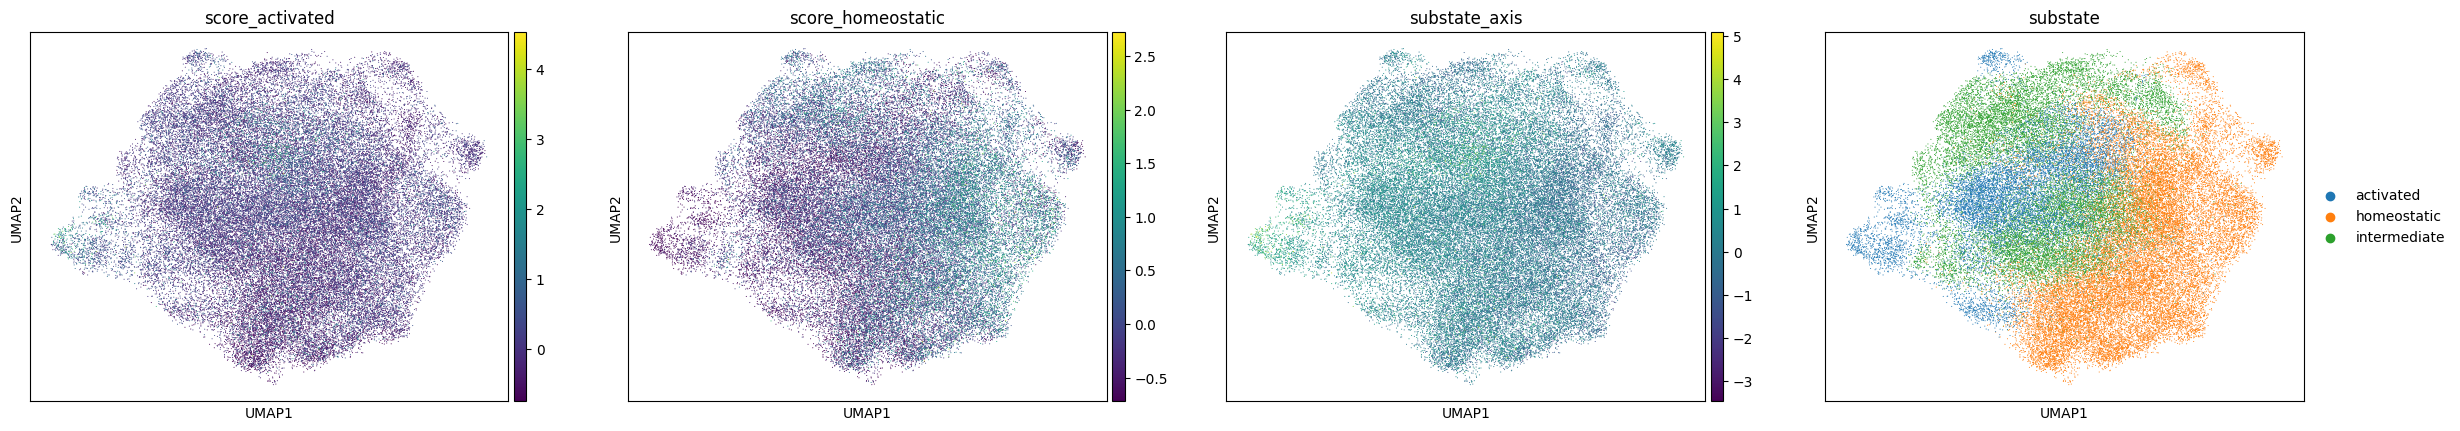

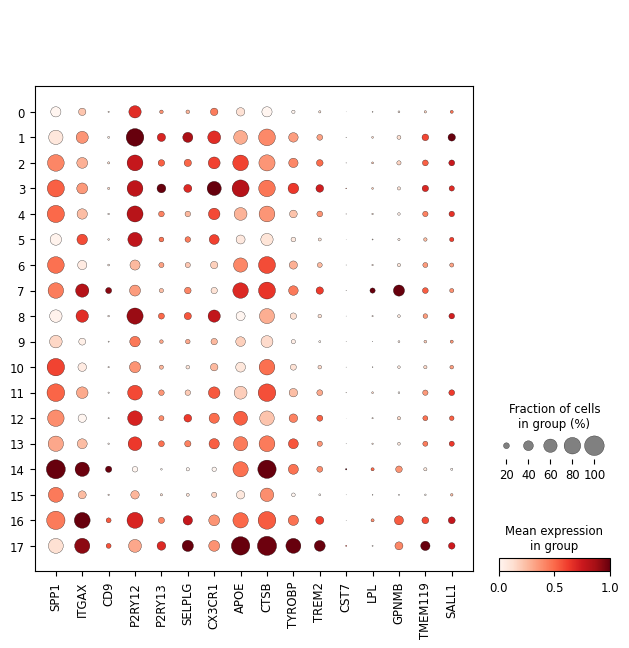

In [6]:
# Microglia substate axis (eval #1 label source) — REBUILT after the first run showed the
# canonical DAM-vs-homeostatic score_genes argmax collapsed 99.5% of cells to "DAM".
# Root cause (confirmed from the 6a signature dotplot): the DAM list was dominated by
# pan-microglial genes (APOE/CTSB/TYROBP/TREM2 high-and-flat in ALL microglia), while the
# DAM-SPECIFIC markers (CST7/LPL/GPNMB) sit at dropout in this intersection snRNA set — so the
# old "DAM score" was really an "is-a-microglia" score. Canonical mouse-DAM is NOT recoverable
# here. The measurable activation program is SPP1/phagocytic (SPP1/ITGAX/CD9, which genuinely
# vary) vs homeostatic (P2RY12/P2RY13/SELPLG/CX3CR1, well-detected). Labeled "activated" NOT
# "DAM" to avoid claiming a mouse template the data cannot support.
#
# Three method fixes vs the first version: (1) trimmed to WELL-MEASURED, DISCRIMINATING genes
# only (drop pan-microglial inflators + dropout genes); (2) z-score each gene across all
# microglia before pooling, so a constitutively-high gene can no longer dominate a pole mean;
# (3) ONE continuous axis = mean(z, activated) - mean(z, homeostatic), with a band around 0 for
# "intermediate" — instead of argmax of two non-comparable absolute scores.
#
# NOT captured: the MHC-II / antigen-presenting activation program (HLA-DRA/CD74/CIITA, micro
# subcluster 15 in the first run) is a DISTINCT state this SPP1/phagocytic axis does not score —
# recorded as a limitation, candidate for a separate label later.
SUBSTATE_SIG = {
    "activated":   ["SPP1", "ITGAX", "CD9"],                  # SPP1/phagocytic activation (DAM-analog)
    "homeostatic": ["P2RY12", "P2RY13", "SELPLG", "CX3CR1"],
}
EXCLUDED_GENES = {  # written into the committed JSON so the exclusion is auditable
    "pan_microglial_inflators": ["APOE", "CTSB", "TYROBP", "TREM2"],
    "dropout_in_this_dataset":  ["CST7", "LPL", "GPNMB", "TMEM119", "SALL1"],
}

sig_present = {k: [g for g in gs if g in micro.var_names] for k, gs in SUBSTATE_SIG.items()}
for k, gs in sig_present.items():
    # fail loud rather than silently scoring an empty pole
    assert gs, f"[substate] {k}: zero genes present in var_names — cannot score this pole"
    miss = set(SUBSTATE_SIG[k]) - set(gs)
    if miss:
        print(f"[substate] {k}: absent from gene set -> {sorted(miss)}")

# z-score each signature gene across ALL microglia on the lognorm layer, then pool
all_sig = sig_present["activated"] + sig_present["homeostatic"]
L = micro.layers["lognorm"][:, [micro.var_names.get_loc(g) for g in all_sig]]
L = L.toarray() if sp.issparse(L) else np.asarray(L)
Z = (L - L.mean(0)) / (L.std(0) + 1e-9)
zdf = pd.DataFrame(Z, columns=all_sig)

micro.obs["score_activated"]   = zdf[sig_present["activated"]].mean(axis=1).values
micro.obs["score_homeostatic"] = zdf[sig_present["homeostatic"]].mean(axis=1).values
micro.obs["substate_axis"]     = micro.obs["score_activated"] - micro.obs["score_homeostatic"]

SUB = micro.obs.groupby("leiden_micro", observed=True)[
    ["score_activated", "score_homeostatic", "substate_axis"]].mean()
print("per-subcluster mean substate scores (z-units) + axis:")
print(SUB.round(3))

# provisional substate per subcluster from the continuous axis. INT_MARGIN is in z-score units
# (per-subcluster mean of activated-minus-homeostatic), an UNVALIDATED placeholder: calibrate
# ONCE post-run against the observed per-subcluster axis distribution (recorded in the interp),
# same "refine at pilot" pattern as the evaluation contract — do NOT treat 0.10 as tuned.
INT_MARGIN = 0.10
def _call(a):
    return "intermediate" if abs(a) < INT_MARGIN else ("activated" if a > 0 else "homeostatic")
sub_assign_axis_only = {cl: _call(row["substate_axis"]) for cl, row in SUB.iterrows()}

# Manual nuisance override (same precedent as CL44_VERDICT — recorded, not silent). The §6b
# donor/study confound check is necessarily narrow (donor>=0.50 or study>=0.60); it does not
# catch every nuisance axis. cl10's top-8 DE genes are Y-linked (UTY/USP9Y/TTTY14) — a sex-driven
# cluster, not activation biology — yet it passes donor/study-unconfounded (top_study_frac=0.590,
# just under the 0.60 threshold) and the raw axis pushed it to "activated" (0.336). Left as-is it
# would inflate the one bucket eval#1 is built to detect signal in, so it is overridden here.
# cl5 (sex) and cl12 (heat-shock) also slip the donor/study check but land in "homeostatic" (the
# majority/default bucket — diluting it, not manufacturing a false activation finding) and are
# left un-overridden, documented as a caveat instead (KNOWN_NUISANCE_UNCONFOUNDED below).
NUISANCE_OVERRIDE = {
    "10": {"to": "intermediate",
           "reason": "sex-driven (Y-linked DE: UTY/USP9Y/TTTY14), not activation biology; "
                     "axis 0.336 not trusted — donor/study check does not catch sex confounds"},
}
sub_assign = dict(sub_assign_axis_only)
for cl_key, ov in NUISANCE_OVERRIDE.items():
    matches = [cl for cl in sub_assign if str(cl) == cl_key]
    assert matches, f"[nuisance override] subcluster {cl_key!r} not found in this run's clusters"
    for cl in matches:
        print(f"[nuisance override] cl{cl_key}: axis-only call "
              f"{sub_assign_axis_only[cl]!r} -> {ov['to']!r} ({ov['reason']})")
        sub_assign[cl] = ov["to"]

KNOWN_NUISANCE_UNCONFOUNDED = {
    "5":  "sex-driven (Y-linked DE), lands homeostatic (majority/default bucket) — not overridden",
    "12": "heat-shock/dissociation-stress driven (HSP90AA1/HSPH1/HSPB1), lands homeostatic — not overridden",
}

# Documents heterogeneity WITHIN the "activated" call (qualitative, from DE + the 6a dotplot) so
# a reader does not treat the bucket as one uniform finding. No code/labeling effect — purely
# carried into the committed JSON per the contract's confound-reporting clause.
ACTIVATED_BUCKET_NOTES = {
    "6":  "unconfounded (Li 0.435/SEA 0.349/Haney 0.217); partial signature (SPP1/ITGAX up, no "
          "CST7/LPL/GPNMB) — the most generalizable activated call",
    "7":  "study-confounded (SEA 0.657); the only subcluster recovering CST7/LPL/GPNMB alongside "
          "SPP1/ITGAX/CD9 — closest to a DAM-like signature, not yet confirmed cross-study",
    "11": "no clear marker identity in DE; study-confounded (0.899)",
    "14": "most extreme axis (1.312) AND most confounded (donor 0.567, study 0.852) — do not "
          "report as a generalizable finding",
    "15": "dissociation-stress signature (FOS/HSPA1A/DUSP1) co-occurring with activation markers; "
          "study-confounded (0.754)",
    "16": "ambient oligodendrocyte contamination (PLP1 in DE); confounded (donor 0.757, study 0.837)",
    "17": "MHC-II/interferon (HLA-DRA/CIITA/B2M); single-donor-driven (0.868) — real biology, not "
          "generalizable (same situation as astro cl33 in colab_05)",
}

micro.obs["substate"] = micro.obs["leiden_micro"].map(sub_assign)
# fail loud on any unmapped subcluster instead of letting .astype(str) mint a silent "nan" label
assert not micro.obs["substate"].isna().any(), "subcluster(s) missing a substate assignment"
micro.obs["substate"] = micro.obs["substate"].astype(str)
print("\nprovisional substate per subcluster (axis-only):", sub_assign_axis_only)
print("provisional substate per subcluster (after nuisance override):", sub_assign)
print("substate cell counts:", micro.obs["substate"].value_counts().to_dict())

# eval#1 leakage guard: the activation pole is donor/study-confounded (see §6b), so record per-
# subcluster donor/study dominance next to each substate call. eval#1's probe MUST use a donor-
# held-out split (like eval#2) — a probe 'win' on a donor-confounded substate would be recovering
# donor/study, not biology.
dom = []
for cl, idx in micro.obs.groupby("leiden_micro", observed=True).groups.items():
    o = micro.obs.loc[idx]
    td = float(o["donor_id"].value_counts(normalize=True).iloc[0])
    ts = float(o["study_id"].value_counts(normalize=True).iloc[0])
    dom.append({"subcluster": str(cl), "n": int(len(o)),
                "substate": sub_assign[cl], "axis_only_call": sub_assign_axis_only[cl],
                "axis": round(float(SUB.loc[cl, "substate_axis"]), 3),
                "top_donor_frac": round(td, 3), "top_study_frac": round(ts, 3),
                "confounded": bool(td >= 0.50 or ts >= 0.60)})
dom_df = pd.DataFrame(dom).set_index("subcluster")
print("\nper-subcluster substate + confound flags:")
print(dom_df)

# committed signature definition (eval#1 label source)
SIG_PATH = os.path.join(REPO_PATH, "outputs", "microglia_substate_signatures.json")
with open(SIG_PATH, "w") as f:
    json.dump({"date": TODAY, "lineage": "microglia",
               "axis": "activated_SPP1_phagocytic_vs_homeostatic",
               "scoring": "per-gene z-score across all microglia (lognorm); pole = mean z; "
                          "substate_axis = activated - homeostatic; cluster-level mean",
               "signatures": SUBSTATE_SIG, "present": sig_present,
               "excluded_genes": EXCLUDED_GENES,
               "intermediate_margin_zunits": INT_MARGIN,
               "per_subcluster": dom,
               "per_subcluster_assignment": sub_assign,
               "per_subcluster_assignment_axis_only": sub_assign_axis_only,
               "nuisance_override": NUISANCE_OVERRIDE,
               "known_nuisance_unconfounded": KNOWN_NUISANCE_UNCONFOUNDED,
               "activated_bucket_heterogeneity_notes": ACTIVATED_BUCKET_NOTES,
               "eval1_requirements": {
                   "labels": ["activated", "homeostatic", "intermediate"],
                   "donor_held_out": True,
                   "reason": "activation pole is donor/study-confounded (see per_subcluster "
                             "confounded flag); a non-donor-held-out probe could recover "
                             "donor/study, not substate"},
               "uncaptured_programs": {
                   "MHC_II_antigen_presenting": ["HLA-DRA", "HLA-DRB1", "CD74", "CIITA"],
                   "note": "distinct activation state not scored by this axis"},
               "note": "expression-signature substate labels for the eval#1 probe; independent of "
                       "FM embeddings (not circular). DAM-vs-homeostatic argmax abandoned after the "
                       "first run (pan-microglial inflation + canonical-DAM-marker dropout). cl10 "
                       "manually re-bucketed (sex confound, see nuisance_override); cl5/cl12 left "
                       "as-is and documented (see known_nuisance_unconfounded)."},
              f, indent=2)
print("saved substate definition ->", SIG_PATH)

# substate-axis UMAP (colors come from .obs — no .X swap needed); rendered inline AND saved
sc.pl.umap(micro, color=["score_activated", "score_homeostatic", "substate_axis", "substate"],
           show=False)
plt.savefig(os.path.join(FIG_DIR, "6a_substate_scores_umap.png"), dpi=150, bbox_inches="tight")
plt.show()  # render inline AND keep the saved PNG

# signature dotplot — used genes + the excluded context genes so the exclusion is visible
X_raw = micro.X
micro.X = micro.layers["lognorm"]
try:
    context = [g for g in (EXCLUDED_GENES["pan_microglial_inflators"]
                           + EXCLUDED_GENES["dropout_in_this_dataset"]) if g in micro.var_names]
    dot_genes = sig_present["activated"] + sig_present["homeostatic"] + context
    sc.pl.dotplot(micro, dot_genes, groupby="leiden_micro", standard_scale="var", show=False)
    plt.savefig(os.path.join(FIG_DIR, "6a_substate_signature_dotplot.png"), dpi=150, bbox_inches="tight")
    plt.show()  # render inline AND keep the saved PNG
finally:
    micro.X = X_raw

> **Interpretation — substate axis: activated vs homeostatic (6a).**
>
> **The axis, and why it was rebuilt.** The first run's canonical DAM-vs-homeostatic argmax collapsed 99.5% of cells to "DAM" — because the DAM list was dominated by **pan-microglial** genes (APOE / CTSB / TYROBP / TREM2, high-and-flat in *all* microglia) while the **DAM-specific** markers (CST7 / LPL / GPNMB) sit at dropout in this snRNA intersection. So the old score was really an "is-a-microglia" score; **canonical mouse DAM is not recoverable in this gene set.** The rebuilt axis scores the program that genuinely varies — **activated/phagocytic (SPP1, ITGAX, CD9) vs homeostatic (P2RY12, P2RY13, SELPLG, CX3CR1)** — each gene z-scored across all microglia, pole = mean z, **`substate_axis = activated − homeostatic`**, with an intermediate band of |axis| < 0.10. Labeled "activated", not "DAM", to avoid claiming a mouse template the data cannot support.
>
> **The split is now non-degenerate:** **homeostatic 25,845 / intermediate 16,851 / activated 12,109** — the 99.5% collapse is fixed. Reading the per-subcluster axis: the homeostatic pole = cl1 (−0.435), cl8 (−0.296); the activated pole = cl14 (**+1.312**, by far the most extreme), cl7 (+0.665), cl15 (+0.407); everything else clusters near 0 (intermediate). The 0.10 band lands in a natural gap — the highest intermediate is cl2 at |0.059|, the nearest activated is cl11 at 0.140, the nearest homeostatic is cl12 at −0.114 — so **no subcluster is a borderline call** (recorded as the calibration check; the placeholder 0.10 is not re-tuned).
>
> **One manual nuisance override (`NUISANCE_OVERRIDE`, recorded not silent).** cl10's raw axis (0.336) called it *activated*, but its top DE genes are Y-linked (UTY / USP9Y / TTTY14) — a **sex** cluster, not activation — and the §6b donor/study check missed it (study 0.590, just under the 0.60 threshold). Left alone it would inflate the one bucket eval#1 is built to detect signal in, so it is re-bucketed to **intermediate**; the axis-only call is preserved in the JSON for audit. cl5 and cl12 slip the same check but land in *homeostatic* (the majority/default bucket — diluting it, not manufacturing a false activation finding) and are documented (`KNOWN_NUISANCE_UNCONFOUNDED`) rather than overridden.
>
> **The critical caveat for eval#1 — the activated bucket is mostly confounded.** Of the 12,109 activated cells, only **cl6 (3,807, ca. 31%) is unconfounded** (Li 0.435 / SEA 0.349 / Haney 0.217; partial signature — the most generalizable call). The rest are study- or donor-dominated: cl7 (study 0.657 — yet the *only* subcluster recovering CST7 / LPL / GPNMB alongside SPP1 / ITGAX / CD9, i.e. the closest DAM-like signal, not cross-study confirmed), cl11 (study 0.899), cl14 (the strongest axis but the most confounded: donor 0.567 + study 0.852 — least trustworthy despite looking strongest), cl15 / cl16 / cl17. This is written into the JSON (`activated_bucket_heterogeneity_notes`) and forces **eval#1 to use a donor-held-out probe** (`eval1_requirements.donor_held_out = true`): a probe "win" on a confounded substate would be recovering donor/study identity, not activation biology.

### 6b — Per-subcluster integrity scan (donor / study / ambient)

The lighter counterpart to colab_05's astrocyte battery. The astrocyte adjudication ran a full six-lever battery because a concrete residual-batch flag (a Li-pure ambient cluster) had been raised; no such flag was raised for microglia, so here we **report** the same per-subcluster diagnostics — dominant-donor fraction, dominant-study fraction, median counts / mito, and an ambient/doublet proxy (oligo / astro / neuron marker leakage) — without committing to the heavy gated 2nd-scVI. A subcluster that is donor-dominated (≥ 50%) or study-dominated (≥ 60%) is flagged for the interp; the gated 2nd-scVI is run **only** if a flagged subcluster also turns out to carry the APOE signal eval #2 depends on. This keeps the integrity claim defensible without process-for-its-own-sake.

In [7]:
# lighter integrity scan: per-subcluster donor/study dominance + ambient/quality proxies
X_raw = micro.X
if "pct_counts_mt" not in micro.obs.columns or "total_counts" not in micro.obs.columns:
    micro.var["mt"] = micro.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(micro, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False)

AMBIENT = [g for g in ["MBP","PLP1","MOBP","AQP4","GFAP","SNAP25","RBFOX3"] if g in micro.var_names]
micro.X = micro.layers["lognorm"]
try:
    sc.tl.score_genes(micro, gene_list=AMBIENT, score_name="score_ambient", use_raw=False)
finally:
    micro.X = X_raw

rows = []
for cl, idx in micro.obs.groupby("leiden_micro", observed=True).groups.items():
    o = micro.obs.loc[idx]
    rows.append({
        "subcluster": cl, "n": len(o),
        "top_donor_frac": round(float(o["donor_id"].value_counts(normalize=True).iloc[0]), 3),
        "top_study_frac": round(float(o["study_id"].value_counts(normalize=True).iloc[0]), 3),
        "median_counts": int(o["total_counts"].median()),
        "median_pct_mt": round(float(o["pct_counts_mt"].median()), 2),
        "mean_ambient": round(float(o["score_ambient"].mean()), 3),
    })
scan = pd.DataFrame(rows).set_index("subcluster")
DONOR_FLAG, STUDY_FLAG = 0.50, 0.60
scan["flag"] = np.where(scan["top_donor_frac"] >= DONOR_FLAG, "donor",
                np.where(scan["top_study_frac"] >= STUDY_FLAG, "study", ""))
print("per-subcluster integrity scan:")
with pd.option_context("display.width", 160):
    print(scan)
flagged = scan[scan["flag"] != ""]
if len(flagged):
    print(f"\n[FLAG] {len(flagged)} subcluster(s) donor/study-dominated — report in interp; "
          f"gated 2nd-scVI ONLY if a flagged cluster also carries the eval#2 APOE signal:")
    print(flagged)
else:
    print("\nno subcluster donor/study-dominated above thresholds — microglia substrate clean")

per-subcluster integrity scan:
               n  top_donor_frac  top_study_frac  median_counts  median_pct_mt  mean_ambient   flag
subcluster                                                                                         
0           6237           0.102           0.910           1371           0.39         0.274  study
1           5718           0.150           0.668           5372           0.39        -0.138  study
2           5716           0.111           0.509           4301           0.43        -0.087       
3           5186           0.128           0.938           3923           0.13        -0.092  study
4           4682           0.110           0.398           3924           0.33        -0.057       
5           4094           0.090           0.589           1875           0.23         0.124       
6           3807           0.110           0.435           3920           0.36        -0.048       
7           3648           0.057           0.657           4075      

> **Interpretation — per-subcluster integrity scan (6b).**
>
> This is the lighter confound scan, deliberately *not* astro's 6-lever battery: per subcluster it prints top-donor and top-study fractions plus quality proxies (median counts, median % mito, mean ambient), and flags **donor ≥ 0.50 or study ≥ 0.60**. **11 of 18 subclusters flag:**
>
> - **donor-dominated (3):** cl14 (0.567), cl16 (0.757), cl17 (0.868) — small subclusters (1,320 / 350 / 228 cells) carried largely by one person.
> - **study-dominated (8):** cl0 (Li 0.910), cl1 (0.668), cl3 (SEA 0.938), cl7 (0.657), cl8 (0.891), cl9 (0.613), cl11 (0.899), cl15 (0.754).
> - **unflagged (7):** cl2, cl4, cl5, cl6, cl10, cl12, cl13.
>
> **"Unflagged" does not mean "clean."** The scan only catches donor/study dominance — it is blind to other nuisance axes. **cl5 and cl10 are both sex-driven** (Y-linked DE) yet pass the threshold (cl10 at study 0.590, just under 0.60); cl10 is the one §6a manually overrode for exactly this gap. cl12 (heat-shock) slips through the same way. So the honest reading is: 11 flagged for donor/study, *plus* at least cl5 / cl10 (sex) and cl12 (heat-shock) carrying nuisance this scan cannot see.
>
> **What this licenses.** The flags do **not** trigger a gated 2nd-scVI — that is reserved for the case where a flagged subcluster *also* carries the eval#2 APOE signal, which this scan does not test. Their role is to be **reported alongside eval#1** (with the confounded-activation caveat from §6a) so a downstream reader never mistakes a donor/study-driven subcluster for a generalizable activation state. The quality proxies also corroborate §4a's cl44 drop: every retained subcluster sits at ca. 1,370–6,900 median counts, far above cl44's 656.

## 7 — Save + handoff

### 7a — Save microglia subset with substate labels; audit trace; commit instructions

Save the microglia subset (raw counts in `.X` for the FM substrate, plus `leiden_micro`, `substate`, and the carried-over `apoe_carrier` / donor / study metadata) to Drive; the working `lognorm` layer is dropped before saving (rebuildable, keeps the file small). Append a `microglia_subset` trace to the cumulative `audit_report.json` and print the WSL commit commands. Committable = env freeze + audit JSON + the substate-signature JSON; the h5ad and figures are Drive- / gitignore-only.

In [8]:
import shlex
# cl44 disposition was already applied in §5a (CL44_VERDICT, default "drop") — no membership
# change is needed here; the verdict is recorded in the audit trace below.

MICRO_DIR = os.path.join(DRIVE_ROOT, "micro_subset")
os.makedirs(MICRO_DIR, exist_ok=True)
if "lognorm" in micro.layers:
    del micro.layers["lognorm"]                       # rebuildable; .X stays raw counts
if sp.issparse(micro.X) and micro.X.getformat() != "csr":
    micro.X = sp.csr_matrix(micro.X)
MICRO_PATH = os.path.join(MICRO_DIR, "micro_subset.h5ad")
micro.write_h5ad(MICRO_PATH)
print("saved microglia subset ->", MICRO_PATH, f"({os.path.getsize(MICRO_PATH)/1e9:.2f} GB)")

AUDIT_REPORT_PATH = os.path.join(REPO_PATH, "outputs", "audit_report.json")
with open(AUDIT_REPORT_PATH) as f:
    report = json.load(f)
report["microglia_subset"] = {
    "status": "computed",
    "date": TODAY,
    "n_microglia": int(micro.n_obs),
    "n_subclusters": int(micro.obs["leiden_micro"].nunique()),
    "subcluster_on": "X_scVI",
    "substate_axis": "activated_SPP1_phagocytic_vs_homeostatic",
    "substate_counts": micro.obs["substate"].value_counts().to_dict(),
    "substate_signatures_file": os.path.relpath(SIG_PATH, REPO_PATH),
    "cl44_verdict": CL44_VERDICT,
}
with open(AUDIT_REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)
print("audit trace appended ->", AUDIT_REPORT_PATH)

rel = [os.path.relpath(p, REPO_PATH) for p in (FREEZE_PATH, ENV_JSON_PATH, AUDIT_REPORT_PATH, SIG_PATH)]
print("\n=== Commit + push (from WSL — Colab has no git creds) ===")
print("  cd /content/ad-glia-fm-prep && git add " + " ".join(shlex.quote(r) for r in rel))
print("  cd /content/ad-glia-fm-prep && git commit -m "
      "'colab_07: microglia subset — cl44 drop, subclustering, activated-vs-homeostatic substate'")
print("  cd /content/ad-glia-fm-prep && git push")

saved microglia subset -> /content/drive/MyDrive/ad-glia-fm-prep/micro_subset/micro_subset.h5ad (0.97 GB)
audit trace appended -> /content/ad-glia-fm-prep/outputs/audit_report.json

=== Commit + push (from WSL — Colab has no git creds) ===
  cd /content/ad-glia-fm-prep && git add outputs/software_versions/colab_07_2026-06-19_pip_freeze.txt outputs/software_versions/colab_07_2026-06-19_env.json outputs/audit_report.json outputs/microglia_substate_signatures.json
  cd /content/ad-glia-fm-prep && git commit -m 'colab_07: microglia subset — cl44 drop, subclustering, activated-vs-homeostatic substate'
  cd /content/ad-glia-fm-prep && git push


> **Interpretation — save + handoff (7a).**
>
> The microglia subset is frozen for the FM notebooks: **`micro_subset.h5ad` (0.97 GB)** written to Drive with `.X` as raw counts (the rebuildable lognorm layer deleted, the matrix forced to CSR for storage). The saved object carries the **post-override `substate` labels** (25,845 / 16,851 / 12,109) — §7a only *reads* the column §6a wrote, it does not re-derive, so cl10 stays in intermediate. The audit trace appended to `audit_report.json` records the substate axis, counts, the cl44 verdict, and the signatures-file pointer; the eval#1 confound requirements live in `microglia_substate_signatures.json`. Commit/push commands are printed for WSL (Colab has no git credentials). **Handoff:** this object plus the substate definition is the eval#1 label source — the activated-bucket confound and the donor-held-out requirement travel with it.

### Carried forward to the FM notebooks

- **Microglia subset** (`micro_subset.h5ad`, raw genes) — the microglia CPT substrate and the eval #1 / eval #2 microglia working set (cl44 dropped).
- **Substate labels** (`substate`: activated / homeostatic / intermediate) + their committed signature definition — the eval #1 label source for microglia. The axis is **SPP1/phagocytic-activated vs homeostatic** (not canonical DAM — see §6a), and eval #1 **must use a donor-held-out split** (activation pole is donor/study-confounded; requirement recorded in the JSON).
- **cl44 disposition** — dropped (low-quality technical pocket); recorded in the audit trace.
- **Still open:** the **astrocyte** substate labels (DAA / resting) are not yet defined — colab_05 gave astrocytes their adjudication but not substate labels. eval #1 needs both lineages' substate labels committed before the probe, so an astrocyte-substate step is the natural next notebook — and it must use the **same rebuilt method** (trim pan-astrocytic inflators, z-score, continuous axis, donor-held-out), since the canonical-marker-argmax trap that broke microglia DAM will recur for astrocyte DAA.